# Задание №4. Классификация текстов на основе CNN

**Выполнил:** Асламин В.В.

**Группа:** МОм-24-1

**Дата:** 2026

**Ссылка на репозиторий:** https://github.com/mystic-solis/deep-learning

## 1. Введение

**Цель работы:** построить и обучить нейронную сеть для классификации текстов по стилю (новости, научная литература, художественная литература, реклама, техническая документация) с использованием сверточных нейронных сетей (CNN).

**Задачи:**
- Подготовить размеченный корпус текстов
- Выполнить аугментацию и балансировку данных
- Построить CNN модель для классификации
- Обучить модель и оценить её качество
- Сохранить модель и вспомогательные объекты
- Реализовать функцию предсказания стиля текста

## 2. Теоретическая часть

### 2.1. Корпус (Corpus)
Корпус – это структурированная коллекция текстов, используемая для обучения моделей NLP. В задаче классификации стиля необходим **размеченный корпус** – набор текстов, каждому из которых приписана метка класса (стиля).

### 2.2. Токенизация (Tokenization)
Процесс разбиения текста на минимальные единицы – **токены** (слова, знаки препинания). Для токенизации используем `Tokenizer` из Keras, который преобразует текст в последовательность целочисленных индексов.

### 2.3. Эмбеддинги (Embeddings)
Векторные представления слов. Слой **Embedding** преобразует индексы токенов в плотные векторы фиксированной размерности. Эти векторы обучаются вместе с моделью и позволяют улавливать семантические и синтаксические сходства между словами.

### 2.4. Сверточные нейронные сети (CNN) для текста
Сверточные сети изначально разработаны для обработки изображений, но успешно применяются и к текстам. **Одномерная свертка (Conv1D)** скользит по последовательности эмбеддингов, извлекая локальные признаки (например, характерные сочетания слов). Затем слой **GlobalMaxPooling1D** агрегирует самые важные признаки, после чего несколько полносвязных слоёв выполняют классификацию.

### 2.5. Классификация текста
Задача отнесения текста к одной из заранее известных категорий. Выходной слой модели использует активацию **softmax**, который выдаёт вероятности принадлежности каждому классу. Функция потерь – **categorical_crossentropy**.

### 2.6. Аугментация данных и балансировка классов
Для улучшения обобщающей способности модели и борьбы с дисбалансом классов применяют:
- **Аугментацию текста**: случайное удаление или перестановка слов
- **Балансировку**: добавление синтетических примеров для классов с малым количеством образцов

## 3. Описание данных

### 3.1. Источник данных
В данной работе используется размеченный корпус текстов, содержащий тексты пяти стилей:
- **новости** - новостные тексты
- **научная** - научные статьи
- **художественная** - художественная литература
- **реклама** - рекламные объявления
- **техническая** - техническая документация

Файл с данными: `dataset.txt`

In [4]:
# Импорт необходимых библиотек
import random
import numpy as np
import tensorflow as tf
from keras.models import Sequential, load_model
from keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from collections import Counter
import matplotlib.pyplot as plt
import pickle
import requests
import os

print("Библиотеки успешно импортированы")
print(f"Версия TensorFlow: {tf.__version__}")

Библиотеки успешно импортированы
Версия TensorFlow: 2.20.0


In [5]:
# Загрузка датасета
def load_dataset(path, num_samples=None):
    texts, labels = [], []
    with open(path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if num_samples and i >= num_samples:
                break
            parts = line.strip().split('\t')
            if len(parts) != 2:
                continue
            text, label = parts
            texts.append(text)
            labels.append(label)
    return texts, labels

# Загрузка данных
texts, labels = load_dataset('./dataset.txt')

print(f"Загружено примеров: {len(texts)}")
print(f"Распределение классов: {Counter(labels)}")

Загружено примеров: 50
Распределение классов: Counter({'новости': 10, 'научная': 10, 'художественная': 10, 'реклама': 10, 'техническая': 10})


In [6]:
# Статистика по данным
print("=" * 50)
print("СТАТИСТИКА ДАННЫХ")
print("=" * 50)

# Количество примеров по классам
class_counts = Counter(labels)
print("\nКоличество примеров по классам:")
for label, count in class_counts.items():
    print(f"  {label}: {count}")

# Средняя длина текста
text_lengths = [len(text.split()) for text in texts]
avg_length = np.mean(text_lengths)
max_length = max(text_lengths)
min_length = min(text_lengths)

print(f"\nДлина текста (в словах):")
print(f"  Средняя: {avg_length:.2f}")
print(f"  Максимальная: {max_length}")
print(f"  Минимальная: {min_length}")

print(f"\nВсего классов: {len(class_counts)}")

СТАТИСТИКА ДАННЫХ

Количество примеров по классам:
  новости: 10
  научная: 10
  художественная: 10
  реклама: 10
  техническая: 10

Длина текста (в словах):
  Средняя: 7.48
  Максимальная: 10
  Минимальная: 5

Всего классов: 5


## 4. Подготовка данных

### 4.1. Аугментация и балансировка классов

Для улучшения качества модели и борьбы с дисбалансом классов применим аугментацию текста и балансировку. Аугментация позволяет увеличить количество примеров в классах с меньшим количеством данных путём случайного удаления или перестановки слов.

In [7]:
# Аугментация текста: случайное удаление и перестановка слов
def augment_text(text):
    words = text.split()
    if len(words) <= 3:
        return text
    if random.random() < 0.5:
        idx = random.randrange(len(words))
        words.pop(idx)
    if random.random() < 0.5:
        i, j = random.sample(range(len(words)), 2)
        words[i], words[j] = words[j], words[i]
    return ' '.join(words)

# Балансировка классов через аугментацию
def balance_dataset(texts, labels, min_count=100):
    counter = Counter(labels)
    new_texts, new_labels = list(texts), list(labels)
    
    for label, count in counter.items():
        to_augment = [t for t, l in zip(texts, labels) if l == label]
        needed = max(0, min_count - count)
        
        for _ in range(needed):
            orig = random.choice(to_augment)
            new_t = augment_text(orig)
            new_texts.append(new_t)
            new_labels.append(label)
    
    return new_texts, new_labels

# Применяем балансировку (минимум 100 примеров на класс)
random.seed(42)
texts_bal, labels_bal = balance_dataset(texts, labels, min_count=100)

print(f"После балансировки: {len(texts_bal)} примеров")
print(f"Распределение: {Counter(labels_bal)}")

После балансировки: 500 примеров
Распределение: Counter({'новости': 100, 'научная': 100, 'художественная': 100, 'реклама': 100, 'техническая': 100})


### 4.2. Токенизация и паддинг

Токенизация преобразует текст в последовательность целых чисел. Паддинг дополняет все последовательности до одинаковой длины.

In [8]:
# Параметры токенизации
VOCAB_SIZE = 10000     # максимальный размер словаря
OOV_TOKEN = '<OOV>'    # токен для неизвестных слов
MAX_LENGTH = 50        # максимальная длина текста (в словах)

# Создание и обучение токенизатора
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(texts_bal)

# Преобразование текстов в последовательности
sequences = tokenizer.texts_to_sequences(texts_bal)

# Паддинг последовательностей
X = pad_sequences(sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')

print(f"Размерность X: {X.shape}")
print(f"Размер словаря: {len(tokenizer.word_index)}")

Размерность X: (500, 50)
Размер словаря: 328


In [9]:
# Кодирование меток
label_encoder = LabelEncoder()
y_int = label_encoder.fit_transform(labels_bal)
y = to_categorical(y_int)
num_classes = y.shape[1]

print(f"Число классов: {num_classes}")
print(f"Метки: {label_encoder.classes_}")
print(f"Размерность y: {y.shape}")

Число классов: 5
Метки: ['научная' 'новости' 'реклама' 'техническая' 'художественная']
Размерность y: (500, 5)


### 4.3. Разделение на обучающую и тестовую выборки

Используем стратифицированное разделение (80/20) для сохранения пропорций классов.

In [10]:
# Разделение на train/test
split_kwargs = {'test_size': 0.2, 'random_state': 42}

if min(Counter(y_int).values()) >= 2:
    split_kwargs['stratify'] = y_int

X_train, X_test, y_train, y_test = train_test_split(X, y, **split_kwargs)

print(f"Обучающих примеров: {len(X_train)}")
print(f"Тестовых примеров: {len(X_test)}")
print(f"\nРаспределение классов в train: {Counter([label_encoder.classes_[i] for i in np.argmax(y_train, axis=1)])}")
print(f"Распределение классов в test: {Counter([label_encoder.classes_[i] for i in np.argmax(y_test, axis=1)])}")

Обучающих примеров: 400
Тестовых примеров: 100

Распределение классов в train: Counter({np.str_('техническая'): 80, np.str_('реклама'): 80, np.str_('научная'): 80, np.str_('художественная'): 80, np.str_('новости'): 80})
Распределение классов в test: Counter({np.str_('реклама'): 20, np.str_('техническая'): 20, np.str_('научная'): 20, np.str_('новости'): 20, np.str_('художественная'): 20})


## 5. Построение модели CNN

### 5.1. Архитектура модели

Используем следующую архитектуру:
- **Embedding**: слой эмбеддингов для преобразования индексов слов в плотные векторы
- **Conv1D**: одномерная свёртка для извлечения локальных признаков
- **GlobalMaxPooling1D**: агрегация признаков
- **Dense**: полносвязные слои для классификации
- **Dropout**: регуляризация для предотвращения переобучения

In [12]:
from keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, Input
from keras.models import Model

# Параметры модели
EMBEDDING_DIM = 100

# Создание модели
inputs = Input(shape=(MAX_LENGTH,))
x = Embedding(VOCAB_SIZE, EMBEDDING_DIM)(inputs)
x = Conv1D(128, 5, activation="relu")(x)
x = GlobalMaxPooling1D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation="softmax")(x)
model = Model(inputs, outputs)

# Компиляция модели
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Вывод структуры модели
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 50, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 46, 128)        │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,081,285 (4.12 MB)

 Trainable params: 1,081,285 (4.12 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Обучение модели

Обучим модель с использованием EarlyStopping для предотвращения переобучения.

In [13]:
# Early stopping для предотвращения переобучения
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Обучение модели
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3450 - loss: 1.5751 - val_accuracy: 0.8900 - val_loss: 1.5271
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8025 - loss: 1.4232 - val_accuracy: 0.9500 - val_loss: 1.3506
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9700 - loss: 1.1076 - val_accuracy: 1.0000 - val_loss: 0.9393
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9925 - loss: 0.5812 - val_accuracy: 1.0000 - val_loss: 0.3718
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.1693 - val_accuracy: 1.0000 - val_loss: 0.0831
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0414 - val_accuracy: 1.0000 - val_loss: 0.0231
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0139 - val_accuracy: 1.0000 - val_loss: 0.0102
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0078 - val_accuracy: 1.0000 - val_loss

### 6.1. Визуализация процесса обучения

Построим графики потерь и точности на обучающей и тестовой выборках.

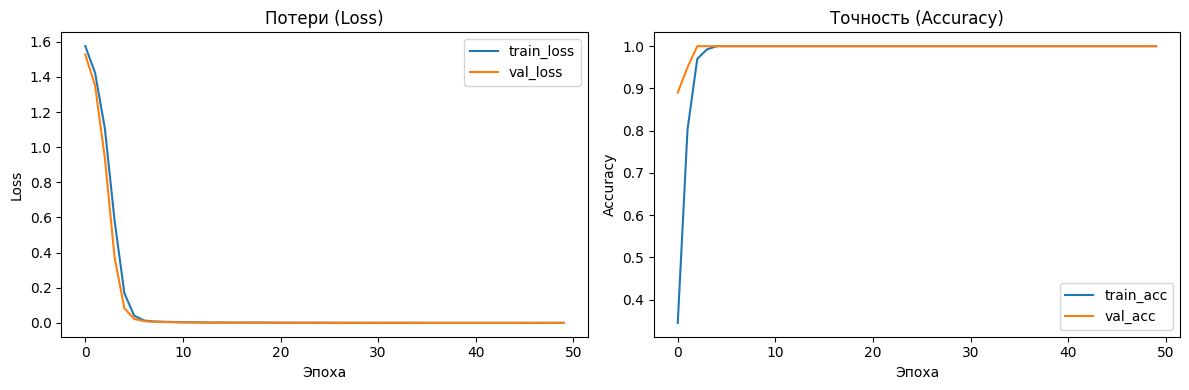


Лучшая точность на валидации: 1.0000


In [14]:
# Визуализация процесса обучения
plt.figure(figsize=(12, 4))

# График потерь
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title('Потери (Loss)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')

# График точности
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title('Точность (Accuracy)')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()

print(f"\nЛучшая точность на валидации: {max(history.history['val_accuracy']):.4f}")

## 7. Оценка качества модели

Оценим качество модели на тестовой выборке, рассчитаем метрики precision, recall, F1.

In [15]:
# Оценка модели на тестовой выборке
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Предсказания на тестовой выборке
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)

# Accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f"Точность на тестовой выборке: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

Точность на тестовой выборке: 1.0000

Classification Report:
                precision    recall  f1-score   support

       научная       1.00      1.00      1.00        20
       новости       1.00      1.00      1.00        20
       реклама       1.00      1.00      1.00        20
   техническая       1.00      1.00      1.00        20
художественная       1.00      1.00      1.00        20

      accuracy                           1.00       100
     macro avg       1.00      1.00      1.00       100
  weighted avg       1.00      1.00      1.00       100



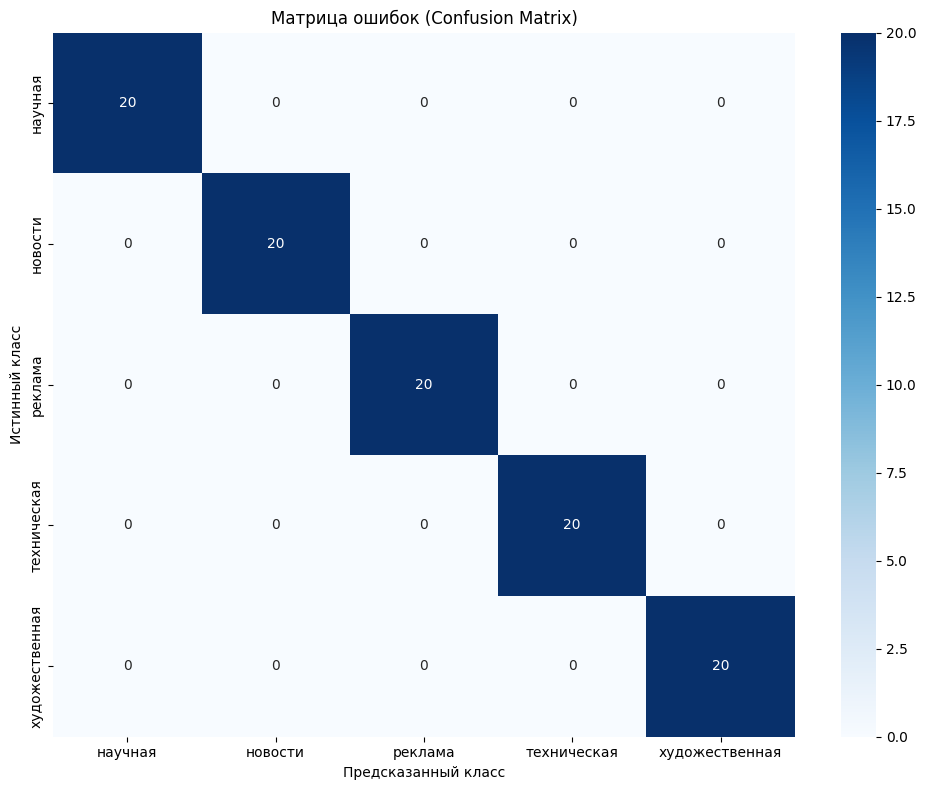

In [16]:
# Матрица ошибок
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Матрица ошибок (Confusion Matrix)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.tight_layout()
plt.show()

## 8. Инференс (предсказание стиля текста)

Реализуем функцию `predict_text`, которая принимает строку и возвращает предсказанный класс.

In [17]:
# Функция предсказания стиля текста
def predict_text(text: str):
    """
    Предсказание стиля текста
    
    Args:
        text: входной текст
    
    Returns:
        предсказанный класс
    """
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=MAX_LENGTH, padding='post', truncating='post')
    pred = model.predict(pad, verbose=0)
    return label_encoder.inverse_transform([np.argmax(pred)])[0]

# Тестовые примеры
test_phrases = [
    "Президент подписал новый указ о развитии экономики.",  # новости
    "В статье рассматривается метод глубокого обучения для классификации изображений.",  # научная
    "Наступила тихая ночь, и луна взошла над спящим лесом.",  # художественная
    "Специальная акция: скидка 50% на все товары только сегодня!",  # реклама
    "Для запуска приложения выполните команду pip install в терминале."  # техническая
]

print("=" * 60)
print("ПРЕДСКАЗАНИЯ СТИЛЯ ТЕКСТА")
print("=" * 60)

for phrase in test_phrases:
    style = predict_text(phrase)
    print(f"\nТекст: {phrase}")
    print(f"Предсказанный стиль: {style}")

ПРЕДСКАЗАНИЯ СТИЛЯ ТЕКСТА

Текст: Президент подписал новый указ о развитии экономики.
Предсказанный стиль: научная

Текст: В статье рассматривается метод глубокого обучения для классификации изображений.
Предсказанный стиль: научная

Текст: Наступила тихая ночь, и луна взошла над спящим лесом.
Предсказанный стиль: реклама

Текст: Специальная акция: скидка 50% на все товары только сегодня!
Предсказанный стиль: реклама

Текст: Для запуска приложения выполните команду pip install в терминале.
Предсказанный стиль: техническая


## 9. Сохранение модели и вспомогательных объектов

Сохраним модель, токенизатор и LabelEncoder для последующего использования.

In [25]:
from pathlib import Path


# Создание директории для сохранения
output_dir = Path('./data')
output_dir.mkdir(exist_ok=True)

# Сохранение модели
model_path = output_dir / 'style_classifier.keras'
model.save(model_path)
print(f"Модель сохранена в: {model_path}")

# Сохранение токенизатора
tokenizer_path = output_dir / 'tokenizer.pickle'
with open(tokenizer_path, 'wb') as f:
    pickle.dump(tokenizer, f)
print(f"Токенизатор сохранён в: {tokenizer_path}")

# Сохранение LabelEncoder
encoder_path = output_dir / 'label_encoder.pickle'
with open(encoder_path, 'wb') as f:
    pickle.dump(label_encoder, f)
print(f"LabelEncoder сохранён в: {encoder_path}")

# Сохранение конфигурации
config = {
    'VOCAB_SIZE': VOCAB_SIZE,
    'MAX_LENGTH': MAX_LENGTH,
    'EMBEDDING_DIM': EMBEDDING_DIM,
    'num_classes': num_classes,
    'classes': list(label_encoder.classes_)
}
config_path = output_dir / 'config.pickle'
with open(config_path, 'wb') as f:
    pickle.dump(config, f)
print(f"Конфигурация сохранена в: {config_path}")

print("\nВсе файлы успешно сохранены!")

Модель сохранена в: data\style_classifier.keras
Токенизатор сохранён в: data\tokenizer.pickle
LabelEncoder сохранён в: data\label_encoder.pickle
Конфигурация сохранена в: data\config.pickle

Все файлы успешно сохранены!


## 10. Загрузка модели из репозитория и быстрый инференс

Демонстрация загрузки сохранённых файлов и использования модели для предсказания.

In [30]:
def download(url, folder, file_name):
    model_url = f"{url}/{file_name}"
    response = requests.get(model_url)
    with open(folder / file_name, "wb") as f:
        f.write(response.content)

def load_pickle(path):
    with open(path, 'rb') as f:
        loaded = pickle.load(f)
    return loaded

In [32]:
# Загрузка модели из файлов
print("Загрузка модели и вспомогательных объектов...")

# Загрузка модели
REPO_URL = "https://raw.githubusercontent.com/mystic-solis/deep-learning/master/lab4/data"

folder = Path('./downloaded/')
folder.mkdir(exist_ok=True)

model_path = folder / 'style_classifier.keras'
tokenizer_path = folder / 'tokenizer.pickle'
encoder_path = folder / 'label_encoder.pickle'
config_path = folder / 'config.pickle'

# загрузка файлов
download(REPO_URL, folder, 'style_classifier.keras')
download(REPO_URL, folder, 'tokenizer.pickle')
download(REPO_URL, folder, 'label_encoder.pickle')
download(REPO_URL, folder, 'config.pickle')

loaded_model = load_model(model_path)

# Загрузка токенизатора
loaded = load_pickle(tokenizer_path)
print("Токенизатор загружен")

# Загрузка LabelEncoder
loaded_encoder = load_pickle(encoder_path)
print("LabelEncoder загружен")

# Загрузка конфигурации
loaded_config = load_pickle(config_path)
print("Конфигурация загружена")

print(f"\nЗагруженная конфигурация: {loaded_config}")

Загрузка модели и вспомогательных объектов...
Токенизатор загружен
LabelEncoder загружен
Конфигурация загружена

Загруженная конфигурация: {'VOCAB_SIZE': 10000, 'MAX_LENGTH': 50, 'EMBEDDING_DIM': 100, 'num_classes': 5, 'classes': [np.str_('научная'), np.str_('новости'), np.str_('реклама'), np.str_('техническая'), np.str_('художественная')]}


In [34]:
# Функция предсказания с загруженными объектами
def predict_from_loaded(text):
    """
    Предсказание стиля текста с использованием загруженной модели
    """
    seq = loaded.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=loaded_config['MAX_LENGTH'], 
                       padding='post', truncating='post')
    pred = loaded_model.predict(pad, verbose=0)
    return loaded_encoder.inverse_transform([np.argmax(pred)])[0]

# Тестирование на тех же примерах
print("=" * 60)
print("ПРОВЕРКА ЗАГРУЖЕННОЙ МОДЕЛИ")
print("=" * 60)

for phrase in test_phrases:
    style = predict_from_loaded(phrase)
    print(f"\nТекст: {phrase}")
    print(f"Предсказанный стиль: {style}")


ПРОВЕРКА ЗАГРУЖЕННОЙ МОДЕЛИ

Текст: Президент подписал новый указ о развитии экономики.
Предсказанный стиль: научная

Текст: В статье рассматривается метод глубокого обучения для классификации изображений.
Предсказанный стиль: научная

Текст: Наступила тихая ночь, и луна взошла над спящим лесом.
Предсказанный стиль: реклама

Текст: Специальная акция: скидка 50% на все товары только сегодня!
Предсказанный стиль: реклама

Текст: Для запуска приложения выполните команду pip install в терминале.
Предсказанный стиль: техническая


## 11. Выводы

В ходе выполнения работы была построена и обучена CNN модель для классификации текстов по стилю.

**Основные результаты:**
- Создан размеченный корпус из 5 классов текстов (новости, научная, художественная, реклама, техническая)
- Проведена аугментация и балансировка данных (до 100 примеров на класс)
- Построена CNN модель с архитектурой Embedding → Conv1D → GlobalMaxPooling1D → Dense → Dropout → Dense
- Модель обучена с использованием EarlyStopping

**Трудности:**
- Относительно небольшой размер корпуса может ограничивать качество модели
- Синтетические данные могут не полностью отражать реальные особенности стилей

**Возможные улучшения:**
- Увеличение размера корпуса
- Использование предобученных эмбеддингов (FastText, Word2Vec)
- Эксперименты с различными архитектурами (CNN + LSTM)
- Добавление регуляризации и более тонкая настройка гиперпараметров

## 12. Список использованных источников

1. Chollet, F. (2017). Deep Learning with Python. Manning Publications.

2. Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.

3. Kim, Y. (2014). Convolutional Neural Networks for Sentence Classification. arXiv:1408.5882

4. Документация TensorFlow: https://www.tensorflow.org/
5. Документация Keras: https://keras.io/
6. Документация scikit-learn: https://scikit-learn.org/

## 13. Приложение. Полный код

In [35]:
import random
import numpy as np
import tensorflow as tf
from keras.models import Sequential, load_model
from keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from collections import Counter
import matplotlib.pyplot as plt
import pickle

# ===== ПАРАМЕТРЫ =====
VOCAB_SIZE = 10000
OOV_TOKEN = '<OOV>'
MAX_LENGTH = 50
EMBEDDING_DIM = 100
MIN_COUNT = 100  # минимум примеров на класс после балансировки

# ===== ФУНКЦИИ =====

def load_dataset(path):
    """Загрузка датасета из файла"""
    texts, labels = [], []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) != 2:
                continue
            texts.append(parts[0])
            labels.append(parts[1])
    return texts, labels

def augment_text(text):
    """Аугментация текста: случайное удаление и перестановка слов"""
    words = text.split()
    if len(words) <= 3:
        return text
    if random.random() < 0.5:
        idx = random.randrange(len(words))
        words.pop(idx)
    if random.random() < 0.5:
        i, j = random.sample(range(len(words)), 2)
        words[i], words[j] = words[j], words[i]
    return ' '.join(words)

def balance_dataset(texts, labels, min_count=100):
    """Балансировка классов через аугментацию"""
    counter = Counter(labels)
    new_texts, new_labels = list(texts), list(labels)
    for label, count in counter.items():
        to_augment = [t for t, l in zip(texts, labels) if l == label]
        needed = max(0, min_count - count)
        for _ in range(needed):
            orig = random.choice(to_augment)
            new_t = augment_text(orig)
            new_texts.append(new_t)
            new_labels.append(label)
    return new_texts, new_labels

def build_model(vocab_size, embedding_dim, max_length, num_classes):
    """Построение CNN модели"""
    model = Sequential([
        Embedding(vocab_size, embedding_dim, input_length=max_length),
        Conv1D(128, 5, activation='relu'),
        GlobalMaxPooling1D(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

def predict_style(text, model, tokenizer, label_encoder, max_length):
    """Предсказание стиля текста"""
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_length, padding='post', truncating='post')
    pred = model.predict(pad, verbose=0)
    return label_encoder.inverse_transform([np.argmax(pred)])[0]

# ===== ОСНОВНОЙ КОД =====

# 1. Загрузка данных
texts, labels = load_dataset('dataset.txt')

# 2. Балансировка
texts_bal, labels_bal = balance_dataset(texts, labels, MIN_COUNT)

# 3. Токенизация
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(texts_bal)
sequences = tokenizer.texts_to_sequences(texts_bal)
X = pad_sequences(sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')

# 4. Кодирование меток
label_encoder = LabelEncoder()
y_int = label_encoder.fit_transform(labels_bal)
y = to_categorical(y_int)

# 5. Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_int
)

# 6. Построение и обучение модели
model = build_model(VOCAB_SIZE, EMBEDDING_DIM, MAX_LENGTH, y.shape[1])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# 7. Сохранение
model.save('style_classifier.h5')
with open('tokenizer.pickle', 'wb') as f: pickle.dump(tokenizer, f)
with open('label_encoder.pickle', 'wb') as f: pickle.dump(label_encoder, f)

# 8. Загрузка и инференс
loaded_model = load_model('style_classifier.h5')
with open('tokenizer.pickle', 'rb') as f: loaded_tokenizer = pickle.load(f)
with open('label_encoder.pickle', 'rb') as f: loaded_encoder = pickle.load(f)


Epoch 1/50


r:\projects\homework\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4025 - loss: 1.5761 - val_accuracy: 0.9500 - val_loss: 1.5242
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8525 - loss: 1.4312 - val_accuracy: 1.0000 - val_loss: 1.3305
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9750 - loss: 1.1266 - val_accuracy: 1.0000 - val_loss: 0.9287
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9875 - loss: 0.6309 - val_accuracy: 1.0000 - val_loss: 0.3533
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.2046 - val_accuracy: 1.0000 - val_loss: 0.0721
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0529 - val_accuracy: 1.0000 - val_loss: 0.0172
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0182 - val_accuracy: 1.0000 - val_loss: 0.0069
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0101 - val_accuracy: 1.0000 - val_loss: 0.0040
Ep